# Image Captioning on the Flicker8k Dataset

This notebook provides you with a rough structure for the Mini-Challenge on the topic of Image Captioning from the Deep Learning MSE course. Please make sure to follow the Project Setup steps to ensure reproducable results. Additionally familiarize yourself with the grading structure and project submission guidelines in the _DL-MPW-ImgCaptioning.pdf_ document. There you'll find all the information you should need. 

If you have any questions please contact roman.studer@fhnw.ch

###  Team Name and Members
<span style="color: red;"><strong>TODO:</strong> Add your teamname and add the names of your team members</span>


### Some Guidelines

- You are allowed to use generative models (e.g. ChatGPT, Claude etc.) for code completion or suggestions. However, we require you to perfectly understand and control the code. 
- You are **not** allowed to use the same or similar generative models for providing reflection on the achieved results. __You__ must reflect about what you see and build your own opinion about it.
- You are allowed to create additional python scripts to outsource code snippets to improve readability.

## Project Setup


### 1. Create the virtual environment

Create a new environment and install the necessary dependencies listed in `requirements.txt`. Make sure you can import the libraries in the code cell below and that yout pytorch installation can run on your GPU.

In [1]:
# [batch] package install skipped - environment pre-provisioned on the cluster.
# (Run the original pip cell only when setting up a fresh local env.)
print('[batch] skipping pip install - using pre-provisioned environment')


[batch] skipping pip install - using pre-provisioned environment


In [2]:
!nvidia-smi

Tue Jun  2 17:48:14 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.126.20             Driver Version: 580.126.20     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L40S                    Off |   00000000:C5:00.0 Off |                    0 |
| N/A   39C    P8             51W /  350W |       0MiB /  46068MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
# imports
import textwrap
import math
import copy
from pathlib import Path
from collections import defaultdict
import kagglehub
import shutil
import os

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torchvision import transforms
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

from dataloader import (
    build_tokenizer_from_split,
    create_caption_dataloader,
    build_captions_map,
    load_split_dataframe,
    load_split_image_ids,
)
from tokenizer import tokenize, CaptionTokenizer

print("torch version:", torch.__version__)
print("torchvision version:", torchvision.__version__)

torch version: 2.11.0+cu130
torchvision version: 0.26.0+cu130


### 2. Download the dataset
The Flickr8k dataset used in this challenge is available under [Flickr 8k Dataset - Kaggle](https://www.kaggle.com/datasets/adityajn105/flickr8k). In the zip folder on Moodle you find the basic structure with `captions.txt` and the `data/splits`-folder, but without images in the `data/images`-folder. Make sure to download all the images and placing them in the folder `data/images/`. 
The train test split is already provided for you and handled by the provided `dataloader.py` script. Test and train split image lists and corresponding captions are located in the `data/splits/` folder. Don't modify this split.

<img src="data_structure.png"/>

In [4]:
# Flickr8k: load from ./data if already staged, otherwise download.
# Safe on the cluster (data pre-staged) AND locally (downloads on first run).
import os, shutil
target_dir = os.path.join(os.getcwd(), "data")

if os.path.isdir(target_dir) and os.listdir(target_dir):
    print(f"Dataset already present at {target_dir} - skipping download")
else:
    import kagglehub
    cache_path = kagglehub.dataset_download("adityajn105/flickr8k")
    shutil.copytree(cache_path, target_dir, dirs_exist_ok=True)
    print(f"Dataset successfully saved to: {target_dir}")


Dataset already present at /cluster/home/magilolg/neural-image-captioning-main/captioning_starter/data - skipping download


## Dataloader, Tokenizer

The repository includes a `Dataset`-class (`Flickr8kCaptionsDatasetBase`) and `DataLoader`'s that are based on this specific structure of the data directory. You can use `create_caption_dataloader` for obtaining instances for the train and test data loaders. You can configure it with the `tokenizer` provided in the repo. The `tokenizer` performs some preprocessing steps of the captions. It also creates a vocabulary from the training data and then provides a mapping from the words to tokens. Note that there are also some special tokens introduced that are important when processing the captions during training or generating the captions during inference:
| Word    | ID | Role |
| --------| ---|----- |
| `<pad>`  | 0 | padding for filling up sequence to a given length in a mini-batch. | 
| `<bos>`  | 1 | beginning of sentence - each tokenized sentence should start with `<bos>`, i.e. also the generated ones. | 
| `<eos>`  | 2 | end of sentence - for fixed length captions will signal that the rest will consist of `<pad>`-tokens only. | 
| `<unk>`  | 3 | unknown - not available in vocabulary | 

Furthermore, specify your transforms used for preprocessing and augmenting the images and pass them to the `create_caption_dataloader`-method.
The mini-batches created by the dataloader have the following structure: `(images, captions, lengths, image_ids, raw_captions)`. Captions are built from the training vocabulary only, and `lengths` may let you mask padding tokens in the loss.


In [5]:
# Transforms
IMAGENET_SIZE = 224
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

def _convert_to_rgb(image: Image.Image) -> Image.Image:
    return image.convert("RGB")

def build_train_transforms() -> transforms.Compose:
    """Training transforms with data augmentation for regularisation."""
    return transforms.Compose([
        transforms.Lambda(_convert_to_rgb),
        # Data augmentation: helps generalisation on small dataset
        transforms.RandomResizedCrop(IMAGENET_SIZE, scale=(0.65, 1.0), ratio=(0.75, 1.33)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
        transforms.RandomGrayscale(p=0.05),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])

def build_test_transforms() -> transforms.Compose:
    """Deterministic test transforms — no augmentation."""
    return transforms.Compose([
        transforms.Lambda(_convert_to_rgb),
        transforms.Resize(256),
        transforms.CenterCrop(IMAGENET_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])

def denormalize_image(image: torch.Tensor) -> torch.Tensor:
    """Undo ImageNet normalisation for visualisation."""
    mean_t = image.new_tensor(IMAGENET_MEAN).view(-1, 1, 1)
    std_t  = image.new_tensor(IMAGENET_STD).view(-1, 1, 1)
    return (image * std_t + mean_t).clamp(0, 1)

In [6]:
# TODO: ADJUST PATH TO data_dir IF NEEDED
data_dir = target_dir

import os
MIN_WORD_FREQ = 5
MAX_LEN       = 40
BATCH_SIZE    = 100                                    # L40S has 46GB — plenty of room
NUM_WORKERS   = min(8, (os.cpu_count() or 4))           # parallel data loading

In [7]:
# Build vocabulary from training captions only (no test leakage).
tokenizer = build_tokenizer_from_split(split="train", data_dir=data_dir, min_freq=MIN_WORD_FREQ)

# create_caption_dataloader (from dataloader.py) accepts num_workers and
# pin_memory; it sets persistent_workers=True internally when num_workers > 0
# and uses PyTorch's default prefetch_factor.
train_loader = create_caption_dataloader(
    split="train",
    data_dir=data_dir,
    tokenizer=tokenizer,
    transform=build_train_transforms(),
    batch_size=BATCH_SIZE,
    max_len=MAX_LEN,
    caption_sampling="all",
    num_workers=NUM_WORKERS,
    pin_memory=True,
)
test_loader = create_caption_dataloader(
    split="test",
    data_dir=data_dir,
    tokenizer=tokenizer,
    transform=build_test_transforms(),
    batch_size=BATCH_SIZE,
    max_len=MAX_LEN,
    caption_sampling="random",
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

# Build reference captions map for BLEU evaluation
test_captions_df  = load_split_dataframe("test", data_dir)
test_captions_map = build_captions_map(test_captions_df)

images, captions, lengths, image_ids, raw_captions = next(iter(train_loader))

print(f"Vocabulary size:                {len(tokenizer):,}")
print(f"Number of training examples:    {len(train_loader.dataset):,}")
print(f"Batch image tensor shape:       {tuple(images.shape)}")
print(f"Batch caption tensor shape:     {tuple(captions.shape)}")
print(f"Caption lengths in first batch: {lengths.tolist()[:6]} ...")
print(f"DataLoader workers:             {train_loader.num_workers}")
print(f"DataLoader pin_memory:          {train_loader.pin_memory}")
print(f"DataLoader persistent_workers:  {train_loader.persistent_workers}")

images, captions, lengths, image_ids, raw_captions = next(iter(test_loader))
print(f"Number of test examples:        {len(test_loader.dataset):,}")
print(f"Batch image tensor shape:       {tuple(images.shape)}")


Vocabulary size:                2,649
Number of training examples:    32,365
Batch image tensor shape:       (100, 3, 224, 224)
Batch caption tensor shape:     (100, 40)
Caption lengths in first batch: [6, 16, 7, 8, 9, 6] ...
DataLoader workers:             8
DataLoader pin_memory:          True
DataLoader persistent_workers:  True
Number of test examples:        1,618
Batch image tensor shape:       (100, 3, 224, 224)


In [8]:
# ══════════════════════════════════════════════════════════════════════════
# SPEEDUP: cache decoded+resized images once (kills JPEG decode + the 5x
# redundant decode caused by caption_sampling="all"). Augmentation stays LIVE
# per-epoch on the cached image, so this does NOT freeze augmentation and does
# NOT change the regularisation — it only removes CPU decode work.
#   - TRAIN: cache decoded PIL (short side 256); random aug applied per access.
#   - TEST : transforms are deterministic, so cache the FINAL tensor (no per-
#            access work at all). The caption is still sampled per access.
# NOTE: the encoder is now TRAINABLE, so we cannot cache encoder *features*
# (they change every epoch). Caching the decoded image is the correct speedup
# for the fine-tuning setup.
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm
from torch.utils.data import DataLoader
from dataloader import (Flickr8kCaptionsDatasetBase, caption_collate_fn,
                        load_split_dataframe)

def build_train_decode_cache(data_dir):
    df  = load_split_dataframe("train", data_dir)
    ids = list(dict.fromkeys(df["image"].tolist()))
    images_dir = Path(data_dir) / "images"
    resize = transforms.Resize(256)                      # short side -> 256, keep aspect
    cache = {}
    for iid in tqdm(ids, desc="decode+resize TRAIN (once)"):
        with Image.open(images_dir / iid) as im:
            cache[iid] = resize(im.convert("RGB")).copy()
    return cache

def build_test_tensor_cache(data_dir, transform, dtype=torch.float16):
    df  = load_split_dataframe("test", data_dir)
    ids = list(dict.fromkeys(df["image"].tolist()))
    images_dir = Path(data_dir) / "images"
    t = torch.empty(len(ids), 3, IMAGENET_SIZE, IMAGENET_SIZE, dtype=dtype)
    for i, iid in enumerate(tqdm(ids, desc="preprocess TEST (once)")):
        with Image.open(images_dir / iid) as im:
            t[i] = transform(im.convert("RGB")).to(dtype)
    return t, {iid: i for i, iid in enumerate(ids)}


class CachedDecodeCaptionDataset(Flickr8kCaptionsDatasetBase):
    """Decode once (cached PIL); augmentation still applied per access."""
    def __init__(self, split, data_dir, tokenizer, transform, image_cache,
                 max_len=40, caption_sampling="all", pad_to_max_len=True):
        super().__init__(split=split, data_dir=data_dir, tokenizer=tokenizer,
                         transform=transform, max_len=max_len,
                         caption_sampling=caption_sampling, pad_to_max_len=pad_to_max_len)
        self._image_cache = image_cache
    def _load_image(self, image_id):
        return self._image_cache[image_id]            # cached RGB PIL


class PrecomputedImageCaptionDataset(Flickr8kCaptionsDatasetBase):
    """Returns a precomputed deterministic image tensor; caption still sampled."""
    def __init__(self, split, data_dir, tokenizer, image_tensors, id_to_row,
                 max_len=40, caption_sampling="random", pad_to_max_len=True):
        super().__init__(split=split, data_dir=data_dir, tokenizer=tokenizer,
                         transform=transforms.Lambda(lambda x: x), max_len=max_len,
                         caption_sampling=caption_sampling, pad_to_max_len=pad_to_max_len)
        self._t = image_tensors
        self._row = id_to_row
    def __getitem__(self, index):
        image_id, raw_caption = self._select_caption(index)
        image = self._t[self._row[image_id]].float()  # fp16 -> fp32
        caption_ids = self.tokenizer.encode(raw_caption, max_len=self.max_len)
        caption_length = len(caption_ids)
        if self.pad_to_max_len:
            caption_ids = caption_ids + [self.tokenizer.pad_idx] * (self.max_len - caption_length)
        return (image,
                torch.tensor(caption_ids, dtype=torch.long),
                torch.tensor(caption_length, dtype=torch.long),
                image_id, raw_caption)


# Build caches once and rebind train_loader / test_loader.
_train_img_cache = build_train_decode_cache(data_dir)
train_dataset = CachedDecodeCaptionDataset(
    split="train", data_dir=data_dir, tokenizer=tokenizer,
    transform=build_train_transforms(), image_cache=_train_img_cache,
    max_len=MAX_LEN, caption_sampling="all",
)
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0), collate_fn=caption_collate_fn,
)

_test_tensors, _test_rows = build_test_tensor_cache(data_dir, build_test_transforms())
test_dataset = PrecomputedImageCaptionDataset(
    split="test", data_dir=data_dir, tokenizer=tokenizer,
    image_tensors=_test_tensors, id_to_row=_test_rows,
    max_len=MAX_LEN, caption_sampling="random",
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=True, collate_fn=caption_collate_fn,
)

print(f"TRAIN loader: decoded-image cache over {len(_train_img_cache):,} unique images "
      f"({len(train_dataset):,} samples), augmentation live, workers={NUM_WORKERS}")
print(f"TEST  loader: {len(_test_tensors):,} precomputed tensors "
      f"({_test_tensors.dtype}), num_workers=0")


decode+resize TRAIN (once):   0%|          | 0/6473 [00:00<?, ?it/s]

preprocess TEST (once):   0%|          | 0/1618 [00:00<?, ?it/s]

TRAIN loader: decoded-image cache over 6,473 unique images (32,365 samples), augmentation live, workers=8
TEST  loader: 1,618 precomputed tensors (torch.float16), num_workers=0


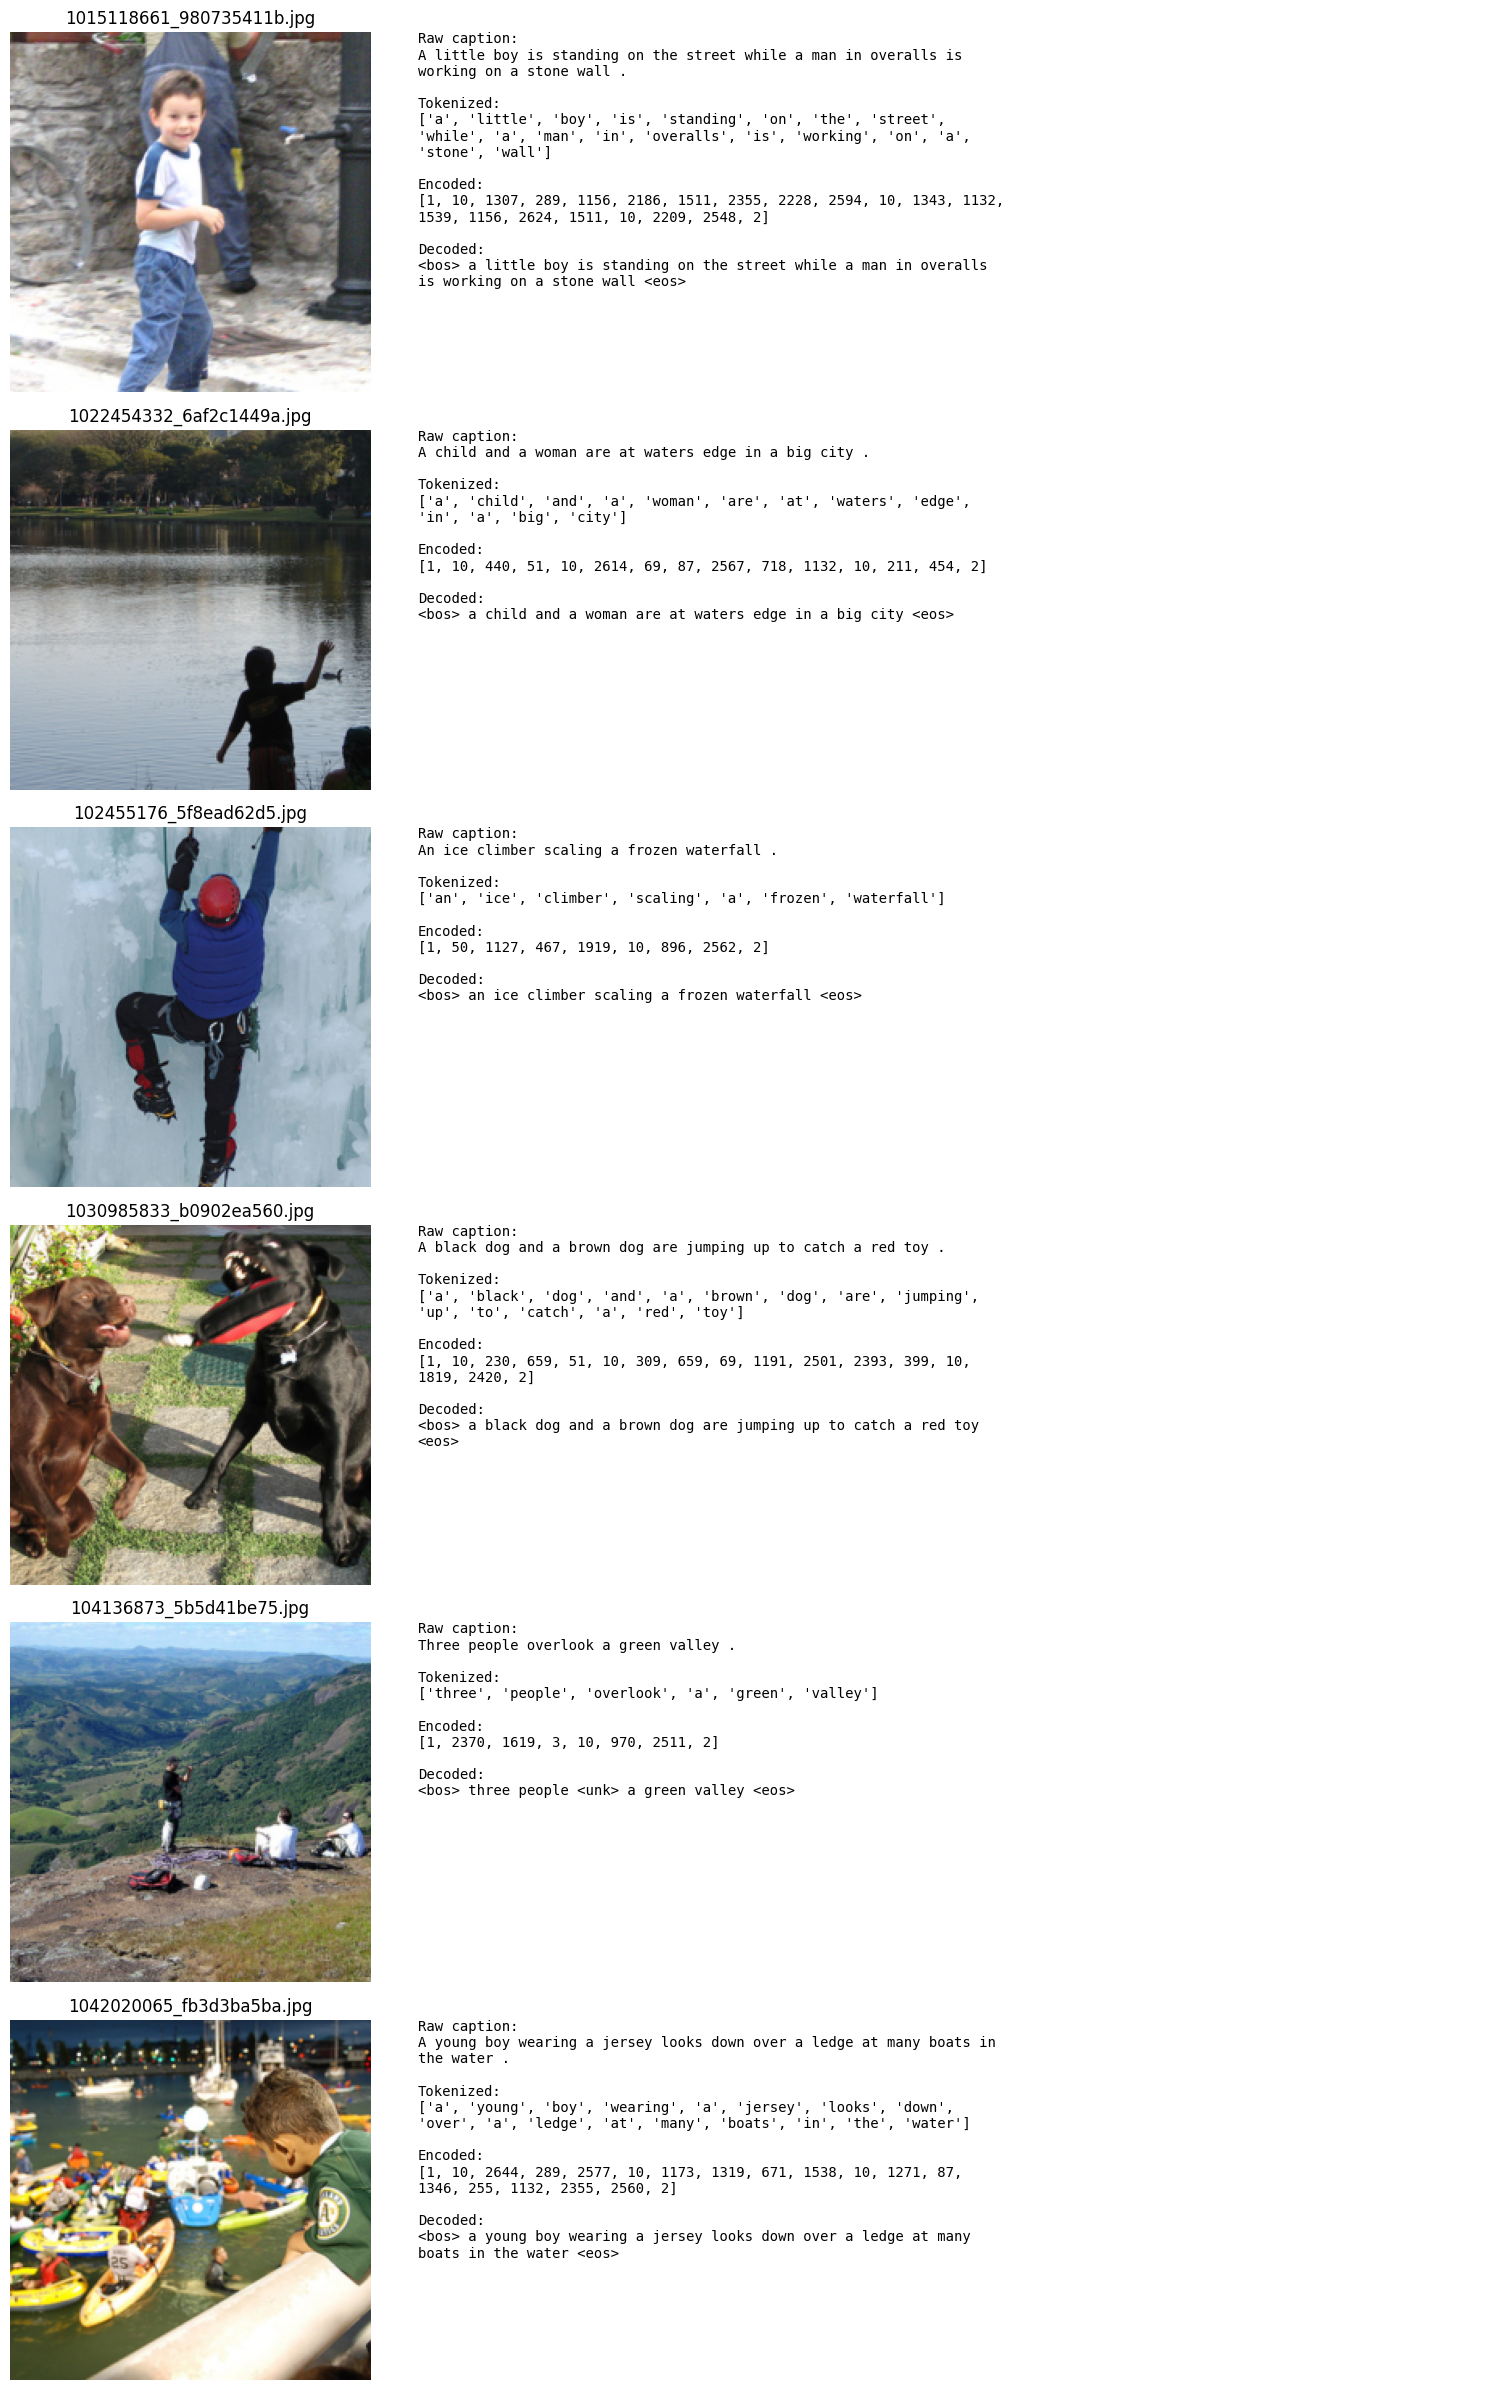

In [9]:
# Visualise a few samples from the test loader
num_examples = 6
n = min(num_examples, len(images))

fig, axes = plt.subplots(
    nrows=n,
    ncols=2,
    figsize=(16, 4 * n),
    gridspec_kw={"width_ratios": [1.1, 2.2]},
)

if n == 1:
    axes = [axes]

for idx in range(n):
    image = denormalize_image(images[idx].detach().cpu()).permute(1, 2, 0)

    encoded_caption  = captions[idx, : int(lengths[idx])].tolist()
    tokenized_caption = tokenize(raw_captions[idx])
    decoded_caption   = tokenizer.decode(encoded_caption, skip_special_tokens=False)

    ax_image, ax_text = axes[idx]
    ax_image.imshow(image)
    ax_image.set_title(image_ids[idx])
    ax_image.axis("off")

    caption_details = "\n\n".join([
        f"Raw caption:\n{textwrap.fill(raw_captions[idx], width=70)}",
        f"Tokenized:\n{textwrap.fill(str(tokenized_caption), width=70)}",
        f"Encoded:\n{textwrap.fill(str(encoded_caption), width=70)}",
        f"Decoded:\n{textwrap.fill(decoded_caption, width=70)}",
    ])

    ax_text.axis("off")
    ax_text.text(0, 1, caption_details, va="top", ha="left", fontsize=10, family="monospace")

plt.tight_layout()
plt.show()

## Shared Utilities

Use this section for shared config and helper functions reused across all experiments. For example define a common training loop, BLEU computation or visualisation helpers here. This way your model models stay directly comparable.


In [10]:
# ── Device ─────────────────────────────────────────────────────────────────
DEVICE = (
    torch.device("cuda") if torch.cuda.is_available()
    else torch.device("mps") if torch.backends.mps.is_available()
    else torch.device("cpu")
)
print("device:", DEVICE)

PAD_IDX = tokenizer.pad_idx  # == 0

import time
from tqdm.auto import tqdm

# Speed knobs --------------------------------------------------------------
# cudnn.benchmark picks the fastest conv algo for our (fixed) input size.
# AMP (mixed precision) gives ~2× speedup on Ada/Ampere/Hopper GPUs.
USE_AMP = (DEVICE.type == "cuda")
if DEVICE.type == "cuda":
    torch.backends.cudnn.benchmark = True
    # bf16 on Ada/Ampere/Hopper avoids the GradScaler overhead; fp16 elsewhere.
    AMP_DTYPE = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
else:
    AMP_DTYPE = torch.float32
print(f"AMP enabled: {USE_AMP} (dtype={AMP_DTYPE})")

# ── Weights & Biases experiment tracking (opt-in) ──────────────────────────
# Set USE_WANDB = True to log per-epoch metrics to a wandb project.
# Requires `pip install wandb` and a `wandb login` once.
USE_WANDB     = True
WANDB_PROJECT = "flickr8k-captioning"
WANDB_ENTITY  = "zhaw-deep-learning"   # your wandb username/team, or None for default

try:
    import wandb
    _WANDB_AVAILABLE = True
except ImportError:
    _WANDB_AVAILABLE = False
    if USE_WANDB:
        print("⚠ USE_WANDB=True but `wandb` is not installed. "
              "Run `pip install wandb` and `wandb login` to enable, "
              "or set USE_WANDB=False. Logging disabled for now.")
        USE_WANDB = False


# ── Loss helper ─────────────────────────────────────────────────────────────
def masked_cross_entropy(logits: torch.Tensor, targets: torch.Tensor, pad_idx: int = 0) -> torch.Tensor:
    """Average cross-entropy over non-padding positions."""
    B, T, V = logits.shape
    return F.cross_entropy(logits.reshape(-1, V), targets.reshape(-1), ignore_index=pad_idx)


# ── Training loop (mixed precision) ────────────────────────────────────────
def train_one_epoch(encoder, decoder, dataloader, optimizer, device,
                    pad_idx=0, epoch=None, n_epochs=None, model_name="model",
                    scaler=None):
    """One epoch of training with AMP, per-batch progress, grad-norm, timing."""
    encoder.train(); decoder.train()
    total_loss, total_tokens_correct, total_tokens = 0.0, 0, 0
    grad_norms = []
    t0 = time.time()

    pbar = tqdm(
        dataloader,
        desc=f"[{model_name}] Epoch {epoch}/{n_epochs}",
        leave=False, dynamic_ncols=True,
    )

    use_scaler = (scaler is not None) and (AMP_DTYPE == torch.float16)

    for step, (images, captions, lengths, _, _) in enumerate(pbar, start=1):
        images   = images.to(device, non_blocking=True)
        captions = captions.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        if USE_AMP:
            with torch.autocast(device_type=device.type, dtype=AMP_DTYPE):
                features = encoder(images)
                logits   = decoder(features, captions)           # (B, T-1, V)
                targets  = captions[:, 1:]
                loss     = masked_cross_entropy(logits, targets, pad_idx)
        else:
            features = encoder(images)
            logits   = decoder(features, captions)
            targets  = captions[:, 1:]
            loss     = masked_cross_entropy(logits, targets, pad_idx)

        # Backward + clip + step
        if use_scaler:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            gnorm = nn.utils.clip_grad_norm_(
                list(encoder.parameters()) + list(decoder.parameters()), max_norm=5.0
            )
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            gnorm = nn.utils.clip_grad_norm_(
                list(encoder.parameters()) + list(decoder.parameters()), max_norm=5.0
            )
            optimizer.step()

        with torch.no_grad():
            preds = logits.argmax(-1)
            mask  = (targets != pad_idx)
            total_tokens_correct += (preds.eq(targets) & mask).sum().item()
            total_tokens         += mask.sum().item()

        total_loss += loss.item()
        grad_norms.append(float(gnorm))

        running_loss = total_loss / step
        running_acc  = total_tokens_correct / max(total_tokens, 1)
        pbar.set_postfix(
            loss=f"{loss.item():.3f}",
            avg=f"{running_loss:.3f}",
            acc=f"{running_acc:.2%}",
            gnorm=f"{float(gnorm):.2f}",
            lr=f"{optimizer.param_groups[0]['lr']:.2e}",
        )

    dt = time.time() - t0
    return {
        "loss":      total_loss / max(len(dataloader), 1),
        "acc":       total_tokens_correct / max(total_tokens, 1),
        "grad_mean": float(np.mean(grad_norms)) if grad_norms else 0.0,
        "grad_max":  float(np.max(grad_norms)) if grad_norms else 0.0,
        "time_s":    dt,
    }


# ── Validation (AMP) — loss + perplexity + token-acc in one pass ───────────
@torch.no_grad()
def evaluate_loss(encoder, decoder, dataloader, device, pad_idx=0):
    """Returns (mean per-batch loss, perplexity, teacher-forced token accuracy)."""
    encoder.eval(); decoder.eval()
    sum_loss_tok, n_tokens = 0.0, 0
    sum_loss_batch, n_batches = 0.0, 0
    correct = 0

    for images, captions, lengths, _, _ in dataloader:
        images   = images.to(device, non_blocking=True)
        captions = captions.to(device, non_blocking=True)

        if USE_AMP:
            with torch.autocast(device_type=device.type, dtype=AMP_DTYPE):
                features = encoder(images)
                logits   = decoder(features, captions)
        else:
            features = encoder(images)
            logits   = decoder(features, captions)

        # cast back to fp32 for stable loss accumulation
        logits  = logits.float()
        targets = captions[:, 1:]

        loss_sum = F.cross_entropy(
            logits.reshape(-1, logits.size(-1)),
            targets.reshape(-1),
            ignore_index=pad_idx, reduction="sum",
        )
        mask = (targets != pad_idx)
        ntok = mask.sum().item()

        sum_loss_tok   += loss_sum.item()
        n_tokens       += ntok
        sum_loss_batch += (loss_sum.item() / max(ntok, 1))
        n_batches      += 1
        correct        += (logits.argmax(-1).eq(targets) & mask).sum().item()

    ppl = math.exp(sum_loss_tok / max(n_tokens, 1))
    return sum_loss_batch / max(n_batches, 1), ppl, correct / max(n_tokens, 1)


# ── Perplexity (kept for backward compatibility) ───────────────────────────
@torch.no_grad()
def compute_perplexity(encoder, decoder, dataloader, device, pad_idx=0) -> float:
    _, ppl, _ = evaluate_loss(encoder, decoder, dataloader, device, pad_idx)
    return ppl


# ── BLEU ────────────────────────────────────────────────────────────────────
@torch.no_grad()
def compute_bleu(encoder, decoder, dataloader, tokenizer, device,
                 captions_map: dict, max_samples: int = 2000) -> dict:
    """Corpus BLEU-1..4 on generated captions vs all reference captions."""
    encoder.eval(); decoder.eval()
    references, hypotheses = [], []
    count = 0
    pbar = tqdm(dataloader, desc="BLEU", leave=False, dynamic_ncols=True)
    for images, captions, lengths, image_ids, raw_caps in pbar:
        if count >= max_samples:
            break
        images = images.to(device, non_blocking=True)
        if USE_AMP:
            with torch.autocast(device_type=device.type, dtype=AMP_DTYPE):
                features  = encoder(images)
                generated = decoder.generate(features, tokenizer, max_len=35)
        else:
            features  = encoder(images)
            generated = decoder.generate(features, tokenizer, max_len=35)
        for i in range(len(image_ids)):
            all_caps = captions_map.get(image_ids[i], [raw_caps[i]])
            references.append([tokenize(c) for c in all_caps])
            hyp_ids = generated[i].cpu().tolist()
            hyp_str = tokenizer.decode(hyp_ids, skip_special_tokens=True, stop_at_eos=True)
            hypotheses.append(tokenize(hyp_str))
        count += len(image_ids)
        pbar.set_postfix(samples=count)

    sf = SmoothingFunction().method1
    return {
        "BLEU-1": corpus_bleu(references, hypotheses, weights=(1,0,0,0), smoothing_function=sf),
        "BLEU-2": corpus_bleu(references, hypotheses, weights=(0.5,0.5,0,0), smoothing_function=sf),
        "BLEU-3": corpus_bleu(references, hypotheses, weights=(1/3,1/3,1/3,0), smoothing_function=sf),
        "BLEU-4": corpus_bleu(references, hypotheses, weights=(0.25,0.25,0.25,0.25), smoothing_function=sf),
    }


# ── Lightweight in-training caption preview ────────────────────────────────
@torch.no_grad()
def _print_sample_captions(encoder, decoder, test_loader, tokenizer, device, n=2):
    encoder.eval(); decoder.eval()
    images, captions, lengths, image_ids, raw_caps = next(iter(test_loader))
    images = images.to(device)
    if USE_AMP:
        with torch.autocast(device_type=device.type, dtype=AMP_DTYPE):
            features  = encoder(images)
            generated = decoder.generate(features, tokenizer, max_len=35)
    else:
        features  = encoder(images)
        generated = decoder.generate(features, tokenizer, max_len=35)
    for i in range(min(n, images.size(0))):
        gen = tokenizer.decode(generated[i].cpu().tolist(),
                               skip_special_tokens=True, stop_at_eos=True)
        print(f"   ✎ ref : {raw_caps[i]}")
        print(f"     gen : {gen}")


# ── Training runner ─────────────────────────────────────────────────────────
def run_training(encoder, decoder, train_loader, test_loader, tokenizer,
                 device, n_epochs=15, lr=4e-4, weight_decay=1e-4,
                 captions_map=None, model_name="model",
                 eval_every=1, bleu_every=0, sample_every=0,
                 encoder_lr=None, warmup_epochs=0, patience=0, min_delta=1e-3,
                 ckpt_dir="checkpoints"):
    """
    Full training loop with verbose per-epoch logging, mixed-precision
    training, and optional periodic validation / BLEU / sample previews.

    Returns dict with train_losses (for backward compat), final perplexity,
    final BLEU, and a full `history` dict for plotting.
    """
    enc_params = sum(p.numel() for p in encoder.parameters() if p.requires_grad)
    dec_params = sum(p.numel() for p in decoder.parameters() if p.requires_grad)
    print("=" * 72)
    print(f" Training: {model_name}")
    print("-" * 72)
    print(f" device          : {device}")
    print(f" AMP             : {USE_AMP} ({AMP_DTYPE})")
    print(f" epochs          : {n_epochs}")
    print(f" lr / wd         : {lr:.2e} / {weight_decay:.2e}")
    print(f" train batches   : {len(train_loader)}   (batch_size={train_loader.batch_size})")
    print(f" val batches     : {len(test_loader)}")
    print(f" encoder params  : {enc_params:,} trainable")
    print(f" decoder params  : {dec_params:,} trainable")
    print(f" eval_every      : {eval_every}    bleu_every: {bleu_every}    sample_every: {sample_every}")
    print(f" decoder lr      : {lr:.2e}")
    print(f" encoder lr      : {('%.2e' % encoder_lr) if encoder_lr is not None else 'tied to decoder lr'}"
          f"   (encoder {'TRAINABLE' if enc_params > 0 else 'frozen'})")
    print(f" warmup epochs   : {warmup_epochs}    early-stop patience: {patience or 'off'}")
    print("=" * 72)

    # Separate param groups so the (now trainable) encoder fine-tunes at a lower
    # LR than the freshly-initialised decoder. Empty groups are skipped, so this
    # also works if the encoder is frozen (decoder-only group).
    _enc_trainable = [p for p in encoder.parameters() if p.requires_grad]
    _dec_trainable = [p for p in decoder.parameters() if p.requires_grad]
    param_groups = []
    if _enc_trainable:
        param_groups.append({"params": _enc_trainable,
                             "lr": (encoder_lr if encoder_lr is not None else lr)})
    if _dec_trainable:
        param_groups.append({"params": _dec_trainable, "lr": lr})
    optimizer = optim.Adam(param_groups, weight_decay=weight_decay)

    # LR schedule: linear warmup over `warmup_epochs`, then cosine decay to 10%
    # of the peak. Applied as a multiplier to every param group.
    def _lr_factor(ep):                      # ep is 0-indexed (LambdaLR convention)
        if warmup_epochs and ep < warmup_epochs:
            return float(ep + 1) / float(warmup_epochs)
        prog = (ep - warmup_epochs) / max(1, n_epochs - warmup_epochs)
        prog = min(1.0, max(0.0, prog))
        return 0.1 + 0.9 * 0.5 * (1.0 + math.cos(math.pi * prog))
    scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=_lr_factor)

    # ── W&B init (no-op if disabled) ──────────────────────────────────────
    wandb_run = None
    if USE_WANDB and _WANDB_AVAILABLE:
        wandb_run = wandb.init(
            project=WANDB_PROJECT, entity=WANDB_ENTITY, name=model_name,
            config={
                "model_name":   model_name,
                "n_epochs":     n_epochs,
                "lr":           lr,
                "weight_decay": weight_decay,
                "batch_size":   train_loader.batch_size,
                "vocab_size":   len(tokenizer),
                "device":       str(device),
                "amp":          USE_AMP,
                "amp_dtype":    str(AMP_DTYPE),
                "encoder_params": enc_params,
                "decoder_params": dec_params,
            },
            reinit=True,
        )

    # GradScaler is only needed for fp16, not bf16 (bf16 has same exponent range as fp32)
    scaler = torch.amp.GradScaler("cuda") if (USE_AMP and AMP_DTYPE == torch.float16) else None

    history = {"train_loss": [], "train_acc": [],
               "val_loss":   [], "val_ppl": [], "val_acc": [],
               "lr": [], "grad_mean": [], "grad_max": [], "epoch_time": []}
    import os as _os
    _os.makedirs(ckpt_dir, exist_ok=True)
    best_val   = float("inf")
    best_epoch = 0
    best_state = None
    no_improve = 0
    epochs_run = 0
    t_start = time.time()

    for epoch in range(1, n_epochs + 1):
        epochs_run = epoch
        cur_lr = optimizer.param_groups[-1]["lr"]   # decoder group = main LR
        tr = train_one_epoch(encoder, decoder, train_loader, optimizer, device,
                             epoch=epoch, n_epochs=n_epochs, model_name=model_name,
                             scaler=scaler)
        scheduler.step()

        history["train_loss"].append(tr["loss"])
        history["train_acc"].append(tr["acc"])
        history["grad_mean"].append(tr["grad_mean"])
        history["grad_max"].append(tr["grad_max"])
        history["epoch_time"].append(tr["time_s"])
        history["lr"].append(cur_lr)

        line = (f"[{model_name}] Epoch {epoch:02d}/{n_epochs} "
                f"| train_loss={tr['loss']:.4f} acc={tr['acc']:.2%} "
                f"| gnorm μ={tr['grad_mean']:.2f} max={tr['grad_max']:.2f} "
                f"| lr={cur_lr:.2e} | {tr['time_s']:.1f}s")

        if eval_every and (epoch % eval_every == 0):
            v_loss, v_ppl, v_acc = evaluate_loss(encoder, decoder, test_loader, device)
            history["val_loss"].append(v_loss)
            history["val_ppl"].append(v_ppl)
            history["val_acc"].append(v_acc)
            if v_loss < best_val - min_delta:
                best_val   = v_loss
                best_epoch = epoch
                no_improve = 0
                best_state = {"encoder": copy.deepcopy(encoder.state_dict()),
                              "decoder": copy.deepcopy(decoder.state_dict())}
                torch.save({**best_state, "epoch": epoch, "val_loss": v_loss,
                            "model_name": model_name},
                           _os.path.join(ckpt_dir, f"{model_name}_best.pt"))
                tag = "  ← new best (checkpointed)"
            else:
                no_improve += 1
                tag = ""
            line += f" | val_loss={v_loss:.4f} ppl={v_ppl:.2f} acc={v_acc:.2%}{tag}"
        else:
            history["val_loss"].append(None)
            history["val_ppl"].append(None)
            history["val_acc"].append(None)

        print(line)

        # ── W&B per-epoch log ─────────────────────────────────────────────
        if wandb_run is not None:
            log_dict = {
                "epoch":      epoch,
                "train/loss": tr["loss"],
                "train/acc":  tr["acc"],
                "train/grad_mean": tr["grad_mean"],
                "train/grad_max":  tr["grad_max"],
                "train/time_s":    tr["time_s"],
                "lr":         cur_lr,
            }
            if history["val_loss"][-1] is not None:
                log_dict["val/loss"] = history["val_loss"][-1]
                log_dict["val/perplexity"] = history["val_ppl"][-1]
                log_dict["val/acc"]  = history["val_acc"][-1]
            wandb_run.log(log_dict, step=epoch)

        if bleu_every and (epoch % bleu_every == 0) and captions_map is not None:
            bleu_mid = compute_bleu(encoder, decoder, test_loader, tokenizer,
                                    device, captions_map, max_samples=500)
            print(f"   ↳ BLEU @ epoch {epoch}:  "
                  + "  ".join(f"{k}={v:.3f}" for k, v in bleu_mid.items()))

        if sample_every and (epoch % sample_every == 0):
            _print_sample_captions(encoder, decoder, test_loader, tokenizer, device, n=2)

        if patience and no_improve >= patience:
            print(f"   stop: no val improvement for {patience} epochs "
                  f"(best val_loss={best_val:.4f} @ epoch {best_epoch})")
            break

    total_time = time.time() - t_start
    print("-" * 72)
    print(f" Training finished in {total_time/60:.1f} min "
          f"({total_time/max(1,epochs_run):.1f}s/epoch over {epochs_run} epochs)")

    # Reload the BEST checkpoint so reported metrics come from the best epoch,
    # not the (often overfit) final epoch.
    if best_state is not None:
        encoder.load_state_dict(best_state["encoder"])
        decoder.load_state_dict(best_state["decoder"])
        print(f" Reloaded BEST checkpoint: epoch {best_epoch}  (val_loss={best_val:.4f})")

    ppl  = compute_perplexity(encoder, decoder, test_loader, device)
    bleu = compute_bleu(encoder, decoder, test_loader, tokenizer, device, captions_map)
    print(f"\n[{model_name}] Final Perplexity: {ppl:.2f}")
    for k, v in bleu.items():
        print(f"   {k}: {v:.4f}")
    print("=" * 72)

    # ── W&B final summary + close run ─────────────────────────────────────
    if wandb_run is not None:
        wandb_run.summary["final/perplexity"] = ppl
        for k, v in bleu.items():
            wandb_run.summary[f"final/{k}"] = v
        wandb_run.summary["total_time_min"] = total_time / 60
        wandb_run.finish()

    return {
        "train_losses":  history["train_loss"],
        "perplexity":    ppl,
        "bleu":          bleu,
        "history":       history,
        "best_epoch":    best_epoch,
        "best_val_loss": best_val,
        "epochs_run":    epochs_run,
    }


# ── Sample caption display ──────────────────────────────────────────────────
@torch.no_grad()
def show_sample_captions(encoder, decoder, test_loader, tokenizer, device, n=6, title=""):
    """Show n images with their generated and reference captions."""
    encoder.eval(); decoder.eval()
    images, captions, lengths, image_ids, raw_captions = next(iter(test_loader))
    images_dev = images.to(device)
    if USE_AMP:
        with torch.autocast(device_type=device.type, dtype=AMP_DTYPE):
            features  = encoder(images_dev)
            generated = decoder.generate(features, tokenizer, max_len=35)
    else:
        features  = encoder(images_dev)
        generated = decoder.generate(features, tokenizer, max_len=35)

    n = min(n, images.size(0))
    fig, axes = plt.subplots(n, 1, figsize=(11, 3.5 * n))
    if n == 1:
        axes = [axes]
    fig.suptitle(title, fontsize=13, weight="bold")
    for i in range(n):
        img = denormalize_image(images[i].cpu()).permute(1, 2, 0).numpy()
        gen_ids = generated[i].cpu().tolist()
        gen_cap = tokenizer.decode(gen_ids, skip_special_tokens=True, stop_at_eos=True)
        axes[i].imshow(img)
        axes[i].set_title(
            f"Generated : {gen_cap}\nReference : {raw_captions[i]}", fontsize=9, loc="left"
        )
        axes[i].axis("off")
    plt.tight_layout()
    plt.show()


# ── Training curve plotter ───────────────────────────────────────────────────
def plot_training_curves(losses_dict: dict, title: str = "Training Loss"):
    fig, ax = plt.subplots(figsize=(9, 4))
    for name, losses in losses_dict.items():
        ax.plot(losses, label=name, linewidth=2)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Cross-Entropy Loss")
    ax.set_title(title); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()


# ── Verbose history plotter (train+val loss, ppl, grad-norm, lr) ────────────
def plot_history(history: dict, model_name: str = "model"):
    """Plot detailed per-epoch diagnostics from a run_training() history dict."""
    epochs = range(1, len(history["train_loss"]) + 1)
    has_val = any(v is not None for v in history["val_loss"])

    fig, axes = plt.subplots(2, 2, figsize=(12, 7))
    fig.suptitle(f"Training diagnostics — {model_name}", fontsize=13, weight="bold")

    ax = axes[0, 0]
    ax.plot(epochs, history["train_loss"], label="train", linewidth=2)
    if has_val:
        val = [v if v is not None else float("nan") for v in history["val_loss"]]
        ax.plot(epochs, val, label="val", linewidth=2)
    ax.set_title("Loss"); ax.set_xlabel("epoch"); ax.set_ylabel("CE loss")
    ax.legend(); ax.grid(alpha=0.3)

    ax = axes[0, 1]
    if has_val:
        ppl = [v if v is not None else float("nan") for v in history["val_ppl"]]
        ax.plot(epochs, ppl, linewidth=2, color="C2")
        ax.set_title("Validation perplexity")
    else:
        ax.set_title("Validation perplexity (not tracked)")
    ax.set_xlabel("epoch"); ax.set_ylabel("perplexity"); ax.grid(alpha=0.3)

    ax = axes[1, 0]
    ax.plot(epochs, history["grad_mean"], label="mean", linewidth=2)
    ax.plot(epochs, history["grad_max"],  label="max",  linewidth=2, alpha=0.6)
    ax.set_title("Gradient norm (pre-clip)"); ax.set_xlabel("epoch"); ax.set_ylabel("‖g‖")
    ax.legend(); ax.grid(alpha=0.3)

    ax = axes[1, 1]
    ax.plot(epochs, history["lr"], linewidth=2, color="C3")
    ax.set_title("Learning rate"); ax.set_xlabel("epoch"); ax.set_ylabel("lr")
    ax.grid(alpha=0.3)

    plt.tight_layout(); plt.show()


device: cuda
AMP enabled: True (dtype=torch.bfloat16)


## Model 1 - Show and Tell

Implement the model described in the [_Show and Tell_](https://arxiv.org/abs/1411.4555) paper. Record the training behaviour, inspect a few generated captions on held-out images, and report BLEU on the fixed evaluation subset.

**Architecture:**
- ResNet-18 CNN encoder (pretrained, final FC removed → global average pool → linear projection)
- LSTM decoder with teacher forcing during training and greedy decoding at inference


In [11]:
# Hyperparameters for Show and Tell
SAT_ENCODER_DIM  = 512   # output dim of the encoder projection
SAT_EMBED_DIM    = 256   # word embedding size
SAT_DECODER_DIM  = 512   # LSTM hidden size
SAT_DROPOUT      = 0.1
SAT_FREEZE_ENC   = False  # UNFROZEN: fine-tune the ResNet encoder (low LR + warmup)
SAT_LR           = 5e-4
SAT_N_EPOCHS     = 100
SAT_WEIGHT_DECAY = 1e-5
SAT_ENCODER_LR   = 1e-5   # low LR for the pretrained backbone
SAT_WARMUP_EPOCHS = 3     # linear LR warmup (epochs)
SAT_PATIENCE     = 8      # early-stop after N epochs w/o val improvement

In [12]:
import torch.nn as nn
import torchvision.models as tvm


# ── Encoder (Show and Tell) ──────────────────────────────────────────────────
class ShowAndTellEncoder(nn.Module):
    """
    ResNet-18 with the classification head replaced by a linear projection.
    Outputs a single global feature vector per image: (B, encoder_dim).
    """
    def __init__(self, encoder_dim: int = 512, freeze: bool = False):
        super().__init__()
        backbone = tvm.resnet18(weights=tvm.ResNet18_Weights.DEFAULT)
        # Keep everything up to (and including) the adaptive avg pool
        self.cnn = nn.Sequential(*list(backbone.children())[:-1])  # → (B, 512, 1, 1)
        self.project = nn.Linear(512, encoder_dim)
        self.bn      = nn.BatchNorm1d(encoder_dim)
        if freeze:
            for p in self.cnn.parameters():
                p.requires_grad = False

    def forward(self, images: torch.Tensor) -> torch.Tensor:
        feat = self.cnn(images).flatten(1)   # (B, 512)
        return self.bn(self.project(feat))   # (B, encoder_dim)


# ── Decoder (Show and Tell) ──────────────────────────────────────────────────
class ShowAndTellDecoder(nn.Module):
    """
    LSTM-based caption decoder.
      forward()  — teacher-forced training pass, returns logits (B, T-1, V)
      generate() — greedy inference, returns token ids  (B, max_len)
    """
    def __init__(self, vocab_size: int, encoder_dim: int, embed_dim: int,
                 decoder_dim: int, dropout: float = 0.5, pad_idx: int = 0):
        super().__init__()
        self.pad_idx = pad_idx
        self.embed   = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.init_h  = nn.Linear(encoder_dim, decoder_dim)
        self.init_c  = nn.Linear(encoder_dim, decoder_dim)
        self.lstm    = nn.LSTMCell(embed_dim, decoder_dim)
        self.drop    = nn.Dropout(dropout)
        self.fc      = nn.Linear(decoder_dim, vocab_size)

    def _init_hidden(self, img_feat: torch.Tensor):
        h = torch.tanh(self.init_h(img_feat))
        c = torch.tanh(self.init_c(img_feat))
        return h, c

    def forward(self, img_feat: torch.Tensor, captions: torch.Tensor) -> torch.Tensor:
        """
        Teacher-forced forward pass.
        img_feat : (B, encoder_dim)
        captions : (B, max_len)  — token ids incl. <bos> … <eos> <pad>…
        Returns logits (B, T-1, vocab_size).
        """
        h, c = self._init_hidden(img_feat)
        embeds = self.drop(self.embed(captions[:, :-1]))  # (B, T-1, E)
        logits = []
        for t in range(embeds.size(1)):
            h, c = self.lstm(embeds[:, t], (h, c))
            logits.append(self.fc(self.drop(h)))
        return torch.stack(logits, dim=1)  # (B, T-1, V)

    @torch.no_grad()
    def generate(self, img_feat: torch.Tensor, tokenizer, max_len: int = 35) -> torch.Tensor:
        """
        Greedy decoding.
        Returns (B, max_len) token ids (not including <bos>).
        """
        self.eval()
        B, device = img_feat.size(0), img_feat.device
        h, c = self._init_hidden(img_feat)
        tok  = torch.full((B,), tokenizer.bos_idx, dtype=torch.long, device=device)
        out  = []
        for _ in range(max_len):
            emb   = self.embed(tok)
            h, c  = self.lstm(emb, (h, c))
            pred  = self.fc(h).argmax(-1)
            out.append(pred)
            tok = pred
        return torch.stack(out, dim=1)  # (B, max_len)


print("ShowAndTellEncoder and ShowAndTellDecoder defined.")

ShowAndTellEncoder and ShowAndTellDecoder defined.


In [13]:
# Instantiate Model 1
sat_encoder = ShowAndTellEncoder(encoder_dim=SAT_ENCODER_DIM, freeze=SAT_FREEZE_ENC).to(DEVICE)
sat_decoder = ShowAndTellDecoder(
    vocab_size=len(tokenizer),
    encoder_dim=SAT_ENCODER_DIM,
    embed_dim=SAT_EMBED_DIM,
    decoder_dim=SAT_DECODER_DIM,
    dropout=SAT_DROPOUT,
    pad_idx=PAD_IDX,
).to(DEVICE)

total_params = sum(p.numel() for p in list(sat_encoder.parameters()) + list(sat_decoder.parameters()))
print(f"Show and Tell total params: {total_params:,}")

# Train
sat_results = run_training(
    encoder=sat_encoder,
    decoder=sat_decoder,
    train_loader=train_loader,
    test_loader=test_loader,
    tokenizer=tokenizer,
    device=DEVICE,
    n_epochs=SAT_N_EPOCHS,
    lr=SAT_LR,
    weight_decay=SAT_WEIGHT_DECAY,
    captions_map=test_captions_map,
    model_name="ShowAndTell",
    encoder_lr=SAT_ENCODER_LR,
    warmup_epochs=SAT_WARMUP_EPOCHS,
    patience=SAT_PATIENCE,
)

Show and Tell total params: 15,579,545
 Training: ShowAndTell
------------------------------------------------------------------------
 device          : cuda
 AMP             : True (torch.bfloat16)
 epochs          : 3
 lr / wd         : 5.00e-04 / 1.00e-05
 train batches   : 324   (batch_size=100)
 val batches     : 17
 encoder params  : 11,440,192 trainable
 decoder params  : 4,139,353 trainable
 eval_every      : 1    bleu_every: 0    sample_every: 0
 decoder lr      : 5.00e-04
 encoder lr      : 1.00e-05   (encoder TRAINABLE)
 warmup epochs   : 3    early-stop patience: 8


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /cluster/home/magilolg/.netrc.
wandb: Currently logged in as: apoptoxin4869 (zhaw-deep-learning) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


[ShowAndTell] Epoch 1/3:   0%|          | 0/324 [00:01<?, ?it/s]

[ShowAndTell] Epoch 01/3 | train_loss=4.8292 acc=22.66% | gnorm μ=0.60 max=1.61 | lr=1.67e-04 | 51.3s | val_loss=4.0109 ppl=55.02 acc=29.54%  ← new best (checkpointed)


[ShowAndTell] Epoch 2/3:   0%|          | 0/324 [00:00<?, ?it/s]

[ShowAndTell] Epoch 02/3 | train_loss=3.6936 acc=31.64% | gnorm μ=0.62 max=0.77 | lr=3.33e-04 | 45.1s | val_loss=3.4296 ppl=30.48 acc=34.29%  ← new best (checkpointed)


[ShowAndTell] Epoch 3/3:   0%|          | 0/324 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# Training curve
plot_training_curves({"Show and Tell": sat_results["train_losses"]}, title="Model 1 — Training Loss")

# Sample captions
show_sample_captions(sat_encoder, sat_decoder, test_loader, tokenizer, DEVICE, n=6,
                     title="Model 1 — Show and Tell")

# Summary table
print("=" * 45)
print(f"  Perplexity : {sat_results['perplexity']:.2f}")
for k, v in sat_results["bleu"].items():
    print(f"  {k}       : {v:.4f}")
print("=" * 45)

Briefly summarize what happened during training, which captions looked convincing or weak, and what the BLEU score does or does not capture for this model.


<span style="color: red;"><strong>TODO:</strong> Write your reflection on Model 1 here.</span>


## Model 2 - Show, Attend and Tell

Now implement the continuation of the Show and Tell paper. An attention-based captioning model described in the paper [_Show, Attend and Tell_](https://arxiv.org/abs/1502.03044). Use the same test data subset and BLEU setup as before, then compare how attention changes the training behavior and generated captions.

**Architecture:**
- ResNet-18 spatial encoder: retains the 7×7 convolutional feature map → (B, 49, 512)
- Additive (Bahdanau) attention: at each decoding step the LSTM attends over the 49 spatial locations
- LSTMCell decoder with context vector concatenated to the word embedding
- Doubly-stochastic attention gate to encourage each feature location to be attended to


In [ ]:
# Hyperparameters for Show, Attend and Tell
SATT_ENCODER_DIM  = 512   # channels in the ResNet-18 spatial feature map
SATT_EMBED_DIM    = 256
SATT_DECODER_DIM  = 512
SATT_ATTENTION_DIM = 256
SATT_DROPOUT       = 0.1
SATT_FREEZE_ENC    = False  # UNFROZEN: fine-tune encoder (low LR + warmup)
SATT_LR            = 5e-4
SATT_N_EPOCHS      = 100
SATT_WEIGHT_DECAY  = 1e-5
SATT_ENCODER_LR    = 1e-5
SATT_WARMUP_EPOCHS = 3
SATT_PATIENCE      = 8

In [ ]:
# ── Encoder (Show, Attend and Tell) ─────────────────────────────────────────
class ShowAttendTellEncoder(nn.Module):
    """
    ResNet-18 with the head removed; retains the 7x7 spatial feature map.
    Outputs (B, 49, 512) — 49 spatial locations, each a 512-d descriptor.
    """
    def __init__(self, freeze: bool = False):
        super().__init__()
        backbone = tvm.resnet18(weights=tvm.ResNet18_Weights.DEFAULT)
        # Layers up to (and including) layer4 — output: (B, 512, 7, 7)
        self.features = nn.Sequential(
            backbone.conv1, backbone.bn1, backbone.relu, backbone.maxpool,
            backbone.layer1, backbone.layer2, backbone.layer3, backbone.layer4,
        )
        if freeze:
            for p in self.features.parameters():
                p.requires_grad = False

    def forward(self, images: torch.Tensor) -> torch.Tensor:
        feat = self.features(images)              # (B, 512, 7, 7)
        B, C, H, W = feat.shape
        feat = feat.permute(0, 2, 3, 1)           # (B, 7, 7, 512)
        return feat.reshape(B, H * W, C)          # (B, 49, 512)


# ── Additive (Bahdanau) Attention ────────────────────────────────────────────
class AdditiveAttention(nn.Module):
    """
    Bahdanau / additive attention as used in Show, Attend and Tell.
    energy_t = v^T tanh(W_enc * encoder_out + W_dec * h_t)
    alpha_t  = softmax(energy_t)
    context  = sum_i alpha_{t,i} * encoder_out_i
    """
    def __init__(self, encoder_dim: int, decoder_dim: int, attention_dim: int):
        super().__init__()
        self.W_enc = nn.Linear(encoder_dim, attention_dim)
        self.W_dec = nn.Linear(decoder_dim, attention_dim)
        self.v     = nn.Linear(attention_dim, 1, bias=False)

    def forward(self, encoder_out: torch.Tensor, h: torch.Tensor):
        # encoder_out : (B, num_pix, enc_dim)
        # h           : (B, dec_dim)
        enc_proj = self.W_enc(encoder_out)                   # (B, P, attn_dim)
        dec_proj = self.W_dec(h).unsqueeze(1)                # (B, 1, attn_dim)
        energy   = self.v(torch.tanh(enc_proj + dec_proj)).squeeze(-1)  # (B, P)
        alpha    = torch.softmax(energy, dim=-1)             # (B, P)
        context  = (encoder_out * alpha.unsqueeze(-1)).sum(1)# (B, enc_dim)
        return context, alpha


# ── Decoder (Show, Attend and Tell) ──────────────────────────────────────────
class ShowAttendTellDecoder(nn.Module):
    """
    LSTM decoder with Bahdanau attention and doubly-stochastic gate.
    forward()                — teacher-forced training
    generate()               — greedy inference
    generate_with_attention()— greedy inference returning attention weights
    """
    def __init__(self, vocab_size: int, encoder_dim: int, embed_dim: int,
                 decoder_dim: int, attention_dim: int,
                 dropout: float = 0.5, pad_idx: int = 0):
        super().__init__()
        self.pad_idx   = pad_idx
        self.attention = AdditiveAttention(encoder_dim, decoder_dim, attention_dim)
        self.embed     = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.init_h    = nn.Linear(encoder_dim, decoder_dim)
        self.init_c    = nn.Linear(encoder_dim, decoder_dim)
        self.lstm      = nn.LSTMCell(embed_dim + encoder_dim, decoder_dim)
        self.beta_gate = nn.Linear(decoder_dim, encoder_dim)   # doubly-stochastic
        self.drop      = nn.Dropout(dropout)
        self.fc        = nn.Linear(decoder_dim, vocab_size)

    def _init_hidden(self, enc_out: torch.Tensor):
        mean_enc = enc_out.mean(1)                   # (B, enc_dim)
        return torch.tanh(self.init_h(mean_enc)), torch.tanh(self.init_c(mean_enc))

    def forward(self, enc_out: torch.Tensor, captions: torch.Tensor) -> torch.Tensor:
        """enc_out: (B, P, enc_dim);  captions: (B, max_len)"""
        h, c  = self._init_hidden(enc_out)
        embeds = self.drop(self.embed(captions[:, :-1]))  # (B, T-1, E)
        logits = []
        for t in range(embeds.size(1)):
            ctx, alpha = self.attention(enc_out, h)
            gate = torch.sigmoid(self.beta_gate(h))
            ctx  = gate * ctx
            h, c = self.lstm(torch.cat([embeds[:, t], ctx], dim=-1), (h, c))
            logits.append(self.fc(self.drop(h)))
        return torch.stack(logits, dim=1)           # (B, T-1, V)

    @torch.no_grad()
    def generate(self, enc_out: torch.Tensor, tokenizer, max_len: int = 35) -> torch.Tensor:
        self.eval()
        B, device = enc_out.size(0), enc_out.device
        h, c = self._init_hidden(enc_out)
        tok  = torch.full((B,), tokenizer.bos_idx, dtype=torch.long, device=device)
        out  = []
        for _ in range(max_len):
            ctx, _ = self.attention(enc_out, h)
            gate   = torch.sigmoid(self.beta_gate(h))
            ctx    = gate * ctx
            h, c   = self.lstm(torch.cat([self.embed(tok), ctx], dim=-1), (h, c))
            pred   = self.fc(h).argmax(-1)
            out.append(pred)
            tok = pred
        return torch.stack(out, dim=1)              # (B, max_len)

    @torch.no_grad()
    def generate_with_attention(self, enc_out: torch.Tensor, tokenizer,
                                max_len: int = 35):
        """Returns (token_ids (B,T), attention_weights (B,T,P))."""
        self.eval()
        B, device = enc_out.size(0), enc_out.device
        h, c = self._init_hidden(enc_out)
        tok  = torch.full((B,), tokenizer.bos_idx, dtype=torch.long, device=device)
        ids_list, alpha_list = [], []
        for _ in range(max_len):
            ctx, alpha = self.attention(enc_out, h)
            gate = torch.sigmoid(self.beta_gate(h))
            ctx  = gate * ctx
            h, c = self.lstm(torch.cat([self.embed(tok), ctx], dim=-1), (h, c))
            pred = self.fc(h).argmax(-1)
            ids_list.append(pred)
            alpha_list.append(alpha)
            tok = pred
        return torch.stack(ids_list, dim=1), torch.stack(alpha_list, dim=1)


print("ShowAttendTellEncoder and ShowAttendTellDecoder defined.")

In [ ]:
# Instantiate Model 2
satt_encoder = ShowAttendTellEncoder(freeze=SATT_FREEZE_ENC).to(DEVICE)
satt_decoder = ShowAttendTellDecoder(
    vocab_size=len(tokenizer),
    encoder_dim=SATT_ENCODER_DIM,
    embed_dim=SATT_EMBED_DIM,
    decoder_dim=SATT_DECODER_DIM,
    attention_dim=SATT_ATTENTION_DIM,
    dropout=SATT_DROPOUT,
    pad_idx=PAD_IDX,
).to(DEVICE)

total_params = sum(p.numel() for p in list(satt_encoder.parameters()) + list(satt_decoder.parameters()))
print(f"Show, Attend and Tell total params: {total_params:,}")

# Train
satt_results = run_training(
    encoder=satt_encoder,
    decoder=satt_decoder,
    train_loader=train_loader,
    test_loader=test_loader,
    tokenizer=tokenizer,
    device=DEVICE,
    n_epochs=SATT_N_EPOCHS,
    lr=SATT_LR,
    weight_decay=SATT_WEIGHT_DECAY,
    captions_map=test_captions_map,
    model_name="ShowAttendTell",
    encoder_lr=SATT_ENCODER_LR,
    warmup_epochs=SATT_WARMUP_EPOCHS,
    patience=SATT_PATIENCE,
)

In [ ]:
# Training curves — both models together
plot_training_curves(
    {"Show and Tell": sat_results["train_losses"],
     "Show, Attend and Tell": satt_results["train_losses"]},
    title="Training Loss Comparison"
)

# Sample captions
show_sample_captions(satt_encoder, satt_decoder, test_loader, tokenizer, DEVICE, n=6,
                     title="Model 2 — Show, Attend and Tell")

# Metric comparison table
print("\n{:<22} {:>10} {:>12}".format("Metric", "Model 1", "Model 2"))
print("-" * 46)
print("{:<22} {:>10.2f} {:>12.2f}".format(
    "Perplexity", sat_results["perplexity"], satt_results["perplexity"]))
for k in ["BLEU-1", "BLEU-2", "BLEU-3", "BLEU-4"]:
    print("{:<22} {:>10.4f} {:>12.4f}".format(k, sat_results["bleu"][k], satt_results["bleu"][k]))

Briefly summarize how this model behaved during training, where attention seemed to help or fail, and how the BLEU score compares to Model 1.


<span style="color: red;"><strong>TODO:</strong> Write your reflection on Model 2 here.</span>


## Additional Task 1: Attention Visualization (Easy)

**Hypothesis:** If the attention mechanism is working correctly, the model should focus on semantically relevant image regions when generating each word (e.g. attend to a dog region when outputting the word *dog*).

**Experiment:** For a handful of test images we run `generate_with_attention()`, decode the caption word-by-word, and overlay the corresponding 7×7 attention map (bilinearly upsampled to 224×224) on top of the original image.

**Expected outcome:** Meaningful attention maps should show high activations near the objects or scene elements described by each token.


In [ ]:
def visualize_attention_for_image(image_tensor: torch.Tensor,
                                   token_ids: torch.Tensor,
                                   attention_weights: torch.Tensor,
                                   tokenizer,
                                   max_words: int = 12):
    """
    Overlay attention heatmaps on the image for each generated word.
    image_tensor      : (3, H, W) — normalised tensor
    token_ids         : (max_len,) — generated ids (no BOS)
    attention_weights : (max_len, num_pixels) — e.g. (35, 49)

    Note: token_ids[t] and attention_weights[t] correspond to the SAME
    decoding step, so we must track the original index when filtering out
    special tokens like <unk>/<bos>/<pad>.
    """
    img_np = denormalize_image(image_tensor.cpu()).permute(1, 2, 0).numpy()
    grid   = int(math.sqrt(attention_weights.shape[-1]))   # 7 for a 7×7 map

    # Decode word by word, KEEPING the original time index for each kept word
    words = []  # list of (word, original_index)
    for orig_idx, tid in enumerate(token_ids.cpu().tolist()):
        word = tokenizer.itos.get(tid, "<unk>")
        if word == "<eos>":
            break
        if word not in ("<bos>", "<pad>", "<unk>"):
            words.append((word, orig_idx))
    words = words[:max_words]

    if not words:
        print("(no decodable words to visualize for this image)")
        return

    cols = 4
    rows = math.ceil((len(words) + 1) / cols)   # +1 for the original image panel
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3.5 * rows),
                             squeeze=False)
    axes = axes.flatten()

    # First panel: original image
    axes[0].imshow(img_np)
    axes[0].set_title("Input image", fontsize=9, weight="bold")
    axes[0].axis("off")

    for panel_idx, (word, orig_idx) in enumerate(words, start=1):
        alpha     = attention_weights[orig_idx].cpu()          # (num_pixels,)
        alpha_map = alpha.reshape(grid, grid).numpy()
        # Normalize for display so the heatmap uses the full dynamic range
        if alpha_map.max() > 0:
            alpha_map = alpha_map / alpha_map.max()
        alpha_up = np.array(
            Image.fromarray((alpha_map * 255).astype(np.uint8)).resize(
                (img_np.shape[1], img_np.shape[0]), resample=Image.BILINEAR
            )
        ) / 255.0
        axes[panel_idx].imshow(img_np)
        axes[panel_idx].imshow(alpha_up, alpha=0.55, cmap="hot", vmin=0)
        axes[panel_idx].set_title(f'"{word}"', fontsize=10)
        axes[panel_idx].axis("off")

    for j in range(len(words) + 1, len(axes)):
        axes[j].axis("off")

    plt.suptitle("Attention maps — Show, Attend and Tell", fontsize=13, weight="bold")
    plt.tight_layout()
    plt.show()


# ── Run visualisation on a few test images ───────────────────────────────────
satt_encoder.eval(); satt_decoder.eval()
vis_images, _, _, _, _ = next(iter(test_loader))
vis_images_dev = vis_images[:4].to(DEVICE)

with torch.no_grad():
    if USE_AMP:
        with torch.autocast(device_type=DEVICE.type, dtype=AMP_DTYPE):
            enc_out = satt_encoder(vis_images_dev)              # (4, 49, 512)
            tok_ids, attn_weights = satt_decoder.generate_with_attention(enc_out, tokenizer)
    else:
        enc_out = satt_encoder(vis_images_dev)
        tok_ids, attn_weights = satt_decoder.generate_with_attention(enc_out, tokenizer)

# Cast to fp32 for matplotlib / numpy ops
attn_weights = attn_weights.float()

for i in range(vis_images_dev.size(0)):
    visualize_attention_for_image(
        image_tensor=vis_images[i],
        token_ids=tok_ids[i],
        attention_weights=attn_weights[i],
        tokenizer=tokenizer,
    )


**Observation (fill in after running):**  
*Describe which words had the most focused attention, whether the model attended to correct regions, and any failure modes you observed.*


## Additional Task 2: Beam Search (Easy)

**Hypothesis:** Beam search should produce more globally coherent captions than greedy decoding because it maintains multiple candidate sequences at each step and therefore avoids locally optimal but globally suboptimal token selections.

**Experiment:** Implement beam search for the Show, Attend and Tell model and compare BLEU scores against greedy decoding on the same test set.


In [ ]:
@torch.no_grad()
def beam_search_single(encoder_out: torch.Tensor, decoder: ShowAttendTellDecoder,
                        tokenizer, beam_size: int = 5, max_len: int = 35) -> list:
    """
    Beam search for a single image.
    encoder_out : (1, num_pixels, encoder_dim)
    Returns list of token ids (best hypothesis, without BOS).
    """
    device = encoder_out.device
    h, c   = decoder._init_hidden(encoder_out)           # (1, dec_dim)

    # Beams: list of (score, token_list, h, c)
    beams     = [(0.0, [tokenizer.bos_idx], h, c)]
    completed = []

    for step in range(max_len):
        all_cands = []
        for score, toks, h_b, c_b in beams:
            tok   = torch.tensor([toks[-1]], dtype=torch.long, device=device)
            emb   = decoder.embed(tok)                   # (1, E)
            ctx, alpha = decoder.attention(encoder_out, h_b)
            gate  = torch.sigmoid(decoder.beta_gate(h_b))
            ctx   = gate * ctx
            h_new, c_new = decoder.lstm(torch.cat([emb, ctx], dim=-1), (h_b, c_b))
            log_probs    = F.log_softmax(decoder.fc(h_new), dim=-1)[0]  # (V,)
            topk_lp, topk_ids = log_probs.topk(beam_size)
            for lp, tid in zip(topk_lp.tolist(), topk_ids.tolist()):
                all_cands.append((score + lp, toks + [tid], h_new, c_new))

        # Sort by score
        all_cands.sort(key=lambda x: x[0], reverse=True)

        beams = []
        for score, toks, h_b, c_b in all_cands:
            if toks[-1] == tokenizer.eos_idx:
                # Normalise by length
                completed.append((score / len(toks), toks[1:]))  # strip BOS
            else:
                beams.append((score, toks, h_b, c_b))
            if len(beams) == beam_size:
                break
        if not beams:
            break

    # Add remaining beams
    for score, toks, h_b, c_b in beams:
        completed.append((score / max(len(toks), 1), toks[1:]))

    completed.sort(key=lambda x: x[0], reverse=True)
    return completed[0][1] if completed else [tokenizer.eos_idx]


@torch.no_grad()
def compute_bleu_beam(encoder, decoder, dataloader, tokenizer, device,
                      captions_map: dict, beam_size: int = 5,
                      max_samples: int = 500) -> dict:
    """BLEU computed using beam-search decoded captions."""
    encoder.eval(); decoder.eval()
    references, hypotheses = [], []
    count = 0
    for images, _, _, image_ids, raw_caps in dataloader:
        if count >= max_samples:
            break
        for i, img in enumerate(images):
            img_dev = img.unsqueeze(0).to(device)
            enc_out = encoder(img_dev)            # (1, P, C)
            best    = beam_search_single(enc_out, decoder, tokenizer,
                                         beam_size=beam_size)
            all_caps = captions_map.get(image_ids[i], [raw_caps[i]])
            references.append([tokenize(c) for c in all_caps])
            hyp_str = tokenizer.decode(best, skip_special_tokens=True, stop_at_eos=True)
            hypotheses.append(tokenize(hyp_str))
            count += 1
            if count >= max_samples:
                break

    sf = SmoothingFunction().method1
    return {
        "BLEU-1": corpus_bleu(references, hypotheses, weights=(1,0,0,0), smoothing_function=sf),
        "BLEU-2": corpus_bleu(references, hypotheses, weights=(.5,.5,0,0), smoothing_function=sf),
        "BLEU-3": corpus_bleu(references, hypotheses, weights=(1/3,1/3,1/3,0), smoothing_function=sf),
        "BLEU-4": corpus_bleu(references, hypotheses, weights=(.25,.25,.25,.25), smoothing_function=sf),
    }


# Evaluate — greedy vs beam (subset for speed)
print("Evaluating Beam Search (beam_size=5) on 500 test samples …")
beam_bleu = compute_bleu_beam(satt_encoder, satt_decoder, test_loader,
                               tokenizer, DEVICE, test_captions_map,
                               beam_size=5, max_samples=500)

greedy_bleu_subset = compute_bleu(satt_encoder, satt_decoder, test_loader,
                                   tokenizer, DEVICE, test_captions_map,
                                   max_samples=500)

print("\n{:<22} {:>12} {:>12}".format("Metric", "Greedy", "Beam (k=5)"))
print("-" * 48)
for k in ["BLEU-1", "BLEU-2", "BLEU-3", "BLEU-4"]:
    print("{:<22} {:>12.4f} {:>12.4f}".format(k, greedy_bleu_subset[k], beam_bleu[k]))

**Observation (fill in after running):**  
*Compare BLEU scores, inspect a few beam-search captions vs greedy, and discuss whether the improvement is consistent.*


## Additional Task 3: Alternative Attention Mechanisms (Moderate)

**Hypothesis:** Scaled dot-product attention (as used in transformer architectures) may converge faster or to a better optimum than additive Bahdanau attention because the multiplicative interaction captures alignment more sharply.

**Experiment:** Replace `AdditiveAttention` with `ScaledDotProductAttention` inside a copy of the Show, Attend and Tell decoder and train it under identical conditions. Compare BLEU and training curves.


In [ ]:
# ── Scaled Dot-Product Attention ────────────────────────────────────────────
class ScaledDotProductAttention(nn.Module):
    """
    Dot-product attention: score = (W_dec * h) · (W_enc * e_i) / sqrt(d)
    where d is the attention dimension.
    """
    def __init__(self, encoder_dim: int, decoder_dim: int, attention_dim: int):
        super().__init__()
        self.W_enc  = nn.Linear(encoder_dim, attention_dim, bias=False)
        self.W_dec  = nn.Linear(decoder_dim, attention_dim, bias=False)
        self.scale  = math.sqrt(attention_dim)

    def forward(self, encoder_out: torch.Tensor, h: torch.Tensor):
        enc_proj = self.W_enc(encoder_out)                        # (B, P, d)
        dec_proj = self.W_dec(h).unsqueeze(2)                     # (B, d, 1)
        energy   = torch.bmm(enc_proj, dec_proj).squeeze(-1) / self.scale  # (B, P)
        alpha    = torch.softmax(energy, dim=-1)
        context  = (encoder_out * alpha.unsqueeze(-1)).sum(1)
        return context, alpha


# ── Decoder variant using dot-product attention ──────────────────────────────
class DotProductAttendTellDecoder(ShowAttendTellDecoder):
    """
    Identical to ShowAttendTellDecoder but uses ScaledDotProductAttention.
    Inherits forward / generate / generate_with_attention unchanged.
    """
    def __init__(self, vocab_size, encoder_dim, embed_dim, decoder_dim,
                 attention_dim, dropout=0.5, pad_idx=0):
        super().__init__(vocab_size, encoder_dim, embed_dim, decoder_dim,
                         attention_dim, dropout, pad_idx)
        # Override the attention module
        self.attention = ScaledDotProductAttention(encoder_dim, decoder_dim, attention_dim)


# ── Train the dot-product variant ────────────────────────────────────────────
dp_encoder = ShowAttendTellEncoder(freeze=SATT_FREEZE_ENC).to(DEVICE)
dp_decoder = DotProductAttendTellDecoder(
    vocab_size=len(tokenizer),
    encoder_dim=SATT_ENCODER_DIM,
    embed_dim=SATT_EMBED_DIM,
    decoder_dim=SATT_DECODER_DIM,
    attention_dim=SATT_ATTENTION_DIM,
    dropout=SATT_DROPOUT,
    pad_idx=PAD_IDX,
).to(DEVICE)

dp_results = run_training(
    encoder=dp_encoder,
    decoder=dp_decoder,
    train_loader=train_loader,
    test_loader=test_loader,
    tokenizer=tokenizer,
    device=DEVICE,
    n_epochs=SATT_N_EPOCHS,
    lr=SATT_LR,
    weight_decay=SATT_WEIGHT_DECAY,
    captions_map=test_captions_map,
    model_name="DotProductAttention",
    encoder_lr=SATT_ENCODER_LR,
    warmup_epochs=SATT_WARMUP_EPOCHS,
    patience=SATT_PATIENCE,
)

In [ ]:
# Compare training curves and metrics: Bahdanau vs Dot-Product
plot_training_curves(
    {"Bahdanau (Additive)": satt_results["train_losses"],
     "Scaled Dot-Product":  dp_results["train_losses"]},
    title="Attention Mechanism Comparison — Training Loss"
)

print("\n{:<22} {:>14} {:>16}".format("Metric", "Bahdanau", "Dot-Product"))
print("-" * 54)
print("{:<22} {:>14.2f} {:>16.2f}".format(
    "Perplexity", satt_results["perplexity"], dp_results["perplexity"]))
for k in ["BLEU-1", "BLEU-2", "BLEU-3", "BLEU-4"]:
    print("{:<22} {:>14.4f} {:>16.4f}".format(
        k, satt_results["bleu"][k], dp_results["bleu"][k]))

**Observation (fill in after running):**  
*Discuss convergence speed, final BLEU, and whether one attention type produces qualitatively better captions.*


## Additional Task 4: Transformer-Based Decoder (Hard)

**Hypothesis:** A transformer decoder with multi-head cross-attention to the spatial image features can model long-range dependencies more effectively than an LSTM, potentially achieving higher BLEU scores.

**Experiment:** Re-use the same `ShowAttendTellEncoder` (spatial 49×512 features) and replace the LSTM with a stack of `nn.TransformerDecoderLayer`s. Compare training curves and BLEU against both LSTM models.


In [ ]:
# ── Transformer-based Captioner ─────────────────────────────────────────────
class TransformerDecoder(nn.Module):
    """
    Transformer decoder for image captioning.
    - Memory: spatial image features from ShowAttendTellEncoder → (B, 49, 512)
    - Target: token embeddings + sinusoidal-style learnable positional encoding
    - Outputs token logits (B, T-1, vocab_size) during training,
      greedy token ids (B, max_len) during inference.
    """
    def __init__(self, vocab_size: int, encoder_dim: int = 512,
                 embed_dim: int = 256, nhead: int = 4,
                 num_layers: int = 3, ffn_dim: int = 1024,
                 dropout: float = 0.1, max_pos: int = 60,
                 pad_idx: int = 0):
        super().__init__()
        assert embed_dim % nhead == 0, "embed_dim must be divisible by nhead"
        self.pad_idx  = pad_idx
        self.embed    = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.pos_emb  = nn.Embedding(max_pos, embed_dim)
        self.enc_proj = nn.Linear(encoder_dim, embed_dim)
        dec_layer = nn.TransformerDecoderLayer(
            d_model=embed_dim, nhead=nhead, dim_feedforward=ffn_dim,
            dropout=dropout, batch_first=True, norm_first=True,
        )
        self.decoder = nn.TransformerDecoder(dec_layer, num_layers=num_layers,
                                              norm=nn.LayerNorm(embed_dim))
        self.fc      = nn.Linear(embed_dim, vocab_size)
        self.drop    = nn.Dropout(dropout)
        self._init_weights()

    def _init_weights(self):
        nn.init.normal_(self.embed.weight, std=0.02)
        nn.init.normal_(self.pos_emb.weight, std=0.02)

    @staticmethod
    def _causal_mask(sz: int, device) -> torch.Tensor:
        return torch.triu(torch.ones(sz, sz, device=device, dtype=torch.bool), diagonal=1)

    def forward(self, enc_out: torch.Tensor, captions: torch.Tensor) -> torch.Tensor:
        """
        enc_out  : (B, num_pixels, encoder_dim)  — from spatial encoder
        captions : (B, max_len)  — includes BOS; target is captions[:, 1:]
        """
        B, device = captions.size(0), captions.device
        tgt = captions[:, :-1]                             # (B, T-1)
        T   = tgt.size(1)

        pos  = torch.arange(T, device=device).unsqueeze(0).expand(B, -1)
        x    = self.drop(self.embed(tgt) + self.pos_emb(pos))   # (B, T-1, E)

        mem  = self.enc_proj(enc_out)                      # (B, P, E)
        mask = self._causal_mask(T, device)
        pad_mask = (tgt == self.pad_idx)                   # (B, T-1) — True = ignore

        out  = self.decoder(x, mem, tgt_mask=mask, tgt_key_padding_mask=pad_mask)
        return self.fc(out)                                # (B, T-1, V)

    @torch.no_grad()
    def generate(self, enc_out: torch.Tensor, tokenizer, max_len: int = 35) -> torch.Tensor:
        self.eval()
        B, device = enc_out.size(0), enc_out.device
        mem = self.enc_proj(enc_out)                       # (B, P, E)
        generated = torch.full((B, 1), tokenizer.bos_idx, dtype=torch.long, device=device)

        for step in range(max_len):
            T   = generated.size(1)
            pos = torch.arange(T, device=device).unsqueeze(0).expand(B, -1)
            x   = self.embed(generated) + self.pos_emb(pos)
            msk = self._causal_mask(T, device)
            out = self.decoder(x, mem, tgt_mask=msk)
            nxt = self.fc(out[:, -1]).argmax(-1, keepdim=True)   # (B, 1)
            generated = torch.cat([generated, nxt], dim=1)
            if (nxt == tokenizer.eos_idx).all():
                break

        return generated[:, 1:]   # strip BOS  →  (B, ≤max_len)


# Shared spatial encoder (same weights as SATT for fair comparison)
tr_encoder = ShowAttendTellEncoder(freeze=SATT_FREEZE_ENC).to(DEVICE)
tr_decoder = TransformerDecoder(
    vocab_size=len(tokenizer),
    encoder_dim=SATT_ENCODER_DIM,
    embed_dim=256,
    nhead=4,
    num_layers=3,
    ffn_dim=1024,
    dropout=0.1,
    max_pos=MAX_LEN + 5,
    pad_idx=PAD_IDX,
).to(DEVICE)

total_params = sum(p.numel() for p in list(tr_encoder.parameters()) + list(tr_decoder.parameters()))
print(f"Transformer Captioner total params: {total_params:,}")

tr_results = run_training(
    encoder=tr_encoder,
    decoder=tr_decoder,
    train_loader=train_loader,
    test_loader=test_loader,
    tokenizer=tokenizer,
    device=DEVICE,
    n_epochs=SATT_N_EPOCHS,
    lr=3e-4,                  # higher peak now that we actually warm up
    weight_decay=1e-4,
    captions_map=test_captions_map,
    model_name="TransformerDecoder",
    encoder_lr=SATT_ENCODER_LR,
    warmup_epochs=5,          # transformer benefits from a longer warmup
    patience=SATT_PATIENCE,
)

In [ ]:
# All four models compared (LSTM + Attention LSTM + DotProduct + Transformer)
plot_training_curves(
    {"Show and Tell (LSTM)":          sat_results["train_losses"],
     "Show, Attend and Tell (LSTM)":  satt_results["train_losses"],
     "Dot-Product Attention (LSTM)":  dp_results["train_losses"],
     "Transformer Decoder":           tr_results["train_losses"]},
    title="Training Loss — All Models"
)

# Sample captions from the transformer
show_sample_captions(tr_encoder, tr_decoder, test_loader, tokenizer, DEVICE, n=6,
                     title="Transformer Decoder — Generated Captions")

# Final metric table — all four models
print("\n{:<26} {:>10} {:>10} {:>12} {:>14}".format(
    "Metric", "M1 (SaT)", "M2 (SATaT)", "M3 (DotPrd)", "M4 (Transf.)"))
print("-" * 76)
print("{:<26} {:>10.2f} {:>10.2f} {:>12.2f} {:>14.2f}".format(
    "Perplexity",
    sat_results["perplexity"], satt_results["perplexity"],
    dp_results["perplexity"], tr_results["perplexity"]))
for k in ["BLEU-1", "BLEU-2", "BLEU-3", "BLEU-4"]:
    print("{:<26} {:>10.4f} {:>10.4f} {:>12.4f} {:>14.4f}".format(
        k,
        sat_results["bleu"][k], satt_results["bleu"][k],
        dp_results["bleu"][k],  tr_results["bleu"][k]))


**Observation (fill in after running):**  
*Discuss differences in convergence, final BLEU, qualitative caption quality, and what you think drives any gap between the LSTM and transformer decoders on this relatively small dataset.*


## Additional Task 5: Pretrained Word Embeddings (GloVe)

**Hypothesis:** On a small dataset like Flickr8k (~6k training images), the word embedding layer has to be learned from very limited language signal. Initializing it from GloVe vectors pretrained on much larger corpora should give the model meaningful word-similarity structure for free, leading to faster convergence and/or better final BLEU.

**Experiment:** Train two variants of *Show and Tell* with `embed_dim=100`:
1. **Control** — random embedding init.
2. **GloVe** — embedding layer initialized from GloVe 6B 100d vectors for vocabulary tokens that appear in GloVe, and random-initialized for the rest. Embeddings are *fine-tuned* (not frozen).

Both variants use identical architecture and hyperparameters; only the embedding initialization differs.


In [ ]:
# ── Download GloVe 6B 100d via kagglehub (≈330 MB) ──────────────────────────
# Tries a cached file first, then falls back to kagglehub. If both fail,
# instructs you to drop the file manually.
def locate_or_download_glove_100d() -> Path:
    """Return a Path to glove.6B.100d.txt, downloading if necessary."""
    cache_candidates = [
        Path.home() / ".cache" / "glove" / "glove.6B.100d.txt",
        Path("/tmp/glove.6B.100d.txt"),
        Path("./glove.6B.100d.txt"),
    ]
    for p in cache_candidates:
        if p.exists() and p.stat().st_size > 100_000_000:   # > 100 MB sanity check
            print(f"Using cached GloVe at: {p}")
            return p

    # kagglehub fallback (already imported in this notebook)
    candidate_slugs = [
        "watts2/glove6b100dtxt",      # 100d-only dataset (~330 MB)
        "anindya2906/glove6b",         # full 6B dataset
        "thanakomsn/glove6b300dtxt",   # 300d (if smaller ones unavailable)
    ]
    for slug in candidate_slugs:
        try:
            print(f"Trying kagglehub: {slug} …")
            d = kagglehub.dataset_download(slug)
            for found in Path(d).rglob("glove.6B.100d.txt"):
                return found
            # If 100d not present, accept whatever GloVe file is largest
            files = sorted(Path(d).rglob("glove.*.txt"),
                            key=lambda p: p.stat().st_size, reverse=True)
            if files:
                print(f"  (using {files[0].name} from this dataset)")
                return files[0]
        except Exception as e:
            print(f"  failed: {e}")

    raise RuntimeError(
        "Could not download GloVe automatically. "
        "Please manually download glove.6B.100d.txt and place it at "
        "~/.cache/glove/glove.6B.100d.txt, then re-run this cell."
    )


def load_glove_vectors(path: Path, dim_hint: int = 100) -> dict:
    """Parse a GloVe text file into {word: np.ndarray(dim,)}. Filters by dim_hint."""
    vectors = {}
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.rstrip().split(" ")
            word = parts[0]
            try:
                vec = np.asarray(parts[1:], dtype=np.float32)
            except ValueError:
                continue
            if vec.shape[0] != dim_hint:
                # If the file has a different dim, infer from the first line
                dim_hint = vec.shape[0]
            vectors[word] = vec
    print(f"Loaded {len(vectors):,} GloVe vectors of dim {dim_hint} from {path.name}")
    return vectors


def init_embedding_from_glove(embed_layer: nn.Embedding,
                              tokenizer,
                              glove_vectors: dict,
                              freeze: bool = False) -> tuple[int, int]:
    """Replace embedding rows for vocab tokens that exist in GloVe.

    Words not in GloVe keep their existing random init (already from
    nn.Embedding's default initializer). Returns (matched, total)."""
    matched, total = 0, len(tokenizer)
    emb_dim = embed_layer.weight.size(1)
    with torch.no_grad():
        for token, idx in tokenizer.stoi.items():
            vec = glove_vectors.get(token)
            if vec is None or vec.shape[0] != emb_dim:
                continue
            embed_layer.weight[idx].copy_(torch.from_numpy(vec))
            matched += 1
    coverage = matched / max(total, 1)
    print(f"GloVe initialization: {matched:,}/{total:,} vocab tokens matched "
          f"({coverage:.1%} coverage)")
    if freeze:
        embed_layer.weight.requires_grad = False
        print("Embedding layer frozen (requires_grad=False).")
    return matched, total


# Download + load now so failures surface before we start training
GLOVE_PATH    = locate_or_download_glove_100d()
GLOVE_VECTORS = load_glove_vectors(GLOVE_PATH, dim_hint=100)
GLOVE_DIM     = next(iter(GLOVE_VECTORS.values())).shape[0]
print(f"\nGloVe embedding dim: {GLOVE_DIM}")


In [ ]:
# ── Train two SaT variants at embed_dim=100 ────────────────────────────────
# Same architecture, same hyperparameters — only the initialization changes.
GLOVE_EMBED_DIM     = 100 #GLOVE_DIM     # 100
GLOVE_N_EPOCHS      = SAT_N_EPOCHS
GLOVE_LR            = SAT_LR
GLOVE_WEIGHT_DECAY  = SAT_WEIGHT_DECAY

# (1) Control — random init, embed_dim=100
print("\n" + "=" * 72)
print(" CONTROL: Show and Tell, embed_dim=100, random embedding init")
print("=" * 72)
rand_encoder = ShowAndTellEncoder(encoder_dim=SAT_ENCODER_DIM, freeze=SAT_FREEZE_ENC).to(DEVICE)
rand_decoder = ShowAndTellDecoder(
    vocab_size=len(tokenizer),
    encoder_dim=SAT_ENCODER_DIM,
    embed_dim=GLOVE_EMBED_DIM,
    decoder_dim=SAT_DECODER_DIM,
    dropout=SAT_DROPOUT,
    pad_idx=PAD_IDX,
).to(DEVICE)
rand_results = run_training(
    encoder=rand_encoder, decoder=rand_decoder,
    train_loader=train_loader, test_loader=test_loader,
    tokenizer=tokenizer, device=DEVICE,
    n_epochs=GLOVE_N_EPOCHS, lr=GLOVE_LR, weight_decay=GLOVE_WEIGHT_DECAY,
    captions_map=test_captions_map, model_name="SaT_embed100_random",
    encoder_lr=SAT_ENCODER_LR, warmup_epochs=SAT_WARMUP_EPOCHS, patience=SAT_PATIENCE,
)

# (2) GloVe-initialized — same model, embedding rows replaced before training
print("\n" + "=" * 72)
print(" GloVe: Show and Tell, embed_dim=100, GloVe embedding init (fine-tuned)")
print("=" * 72)
glove_encoder = ShowAndTellEncoder(encoder_dim=SAT_ENCODER_DIM, freeze=SAT_FREEZE_ENC).to(DEVICE)
glove_decoder = ShowAndTellDecoder(
    vocab_size=len(tokenizer),
    encoder_dim=SAT_ENCODER_DIM,
    embed_dim=GLOVE_EMBED_DIM,
    decoder_dim=SAT_DECODER_DIM,
    dropout=SAT_DROPOUT,
    pad_idx=PAD_IDX,
).to(DEVICE)
init_embedding_from_glove(glove_decoder.embed, tokenizer, GLOVE_VECTORS, freeze=False)
glove_results = run_training(
    encoder=glove_encoder, decoder=glove_decoder,
    train_loader=train_loader, test_loader=test_loader,
    tokenizer=tokenizer, device=DEVICE,
    n_epochs=GLOVE_N_EPOCHS, lr=GLOVE_LR, weight_decay=GLOVE_WEIGHT_DECAY,
    captions_map=test_captions_map, model_name="SaT_embed100_glove",
    encoder_lr=SAT_ENCODER_LR, warmup_epochs=SAT_WARMUP_EPOCHS, patience=SAT_PATIENCE,
)


In [ ]:
# ── Compare random init vs GloVe init ──────────────────────────────────────
plot_training_curves(
    {"Random init (embed_dim=100)": rand_results["train_losses"],
     "GloVe init (embed_dim=100)":  glove_results["train_losses"]},
    title="GloVe vs Random Embedding Initialization — Training Loss"
)

# Also overlay val-loss curves if we have them
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, res in [("Random init", rand_results), ("GloVe init", glove_results)]:
    h = res["history"]
    val = [v if v is not None else float("nan") for v in h["val_loss"]]
    axes[0].plot(range(1, len(h["train_loss"]) + 1), h["train_loss"], label=f"{name} (train)")
    axes[0].plot(range(1, len(val) + 1), val, label=f"{name} (val)", linestyle="--")
    ppl = [v if v is not None else float("nan") for v in h["val_ppl"]]
    axes[1].plot(range(1, len(ppl) + 1), ppl, label=name, linewidth=2)
axes[0].set_title("Loss"); axes[0].set_xlabel("epoch"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_title("Validation perplexity"); axes[1].set_xlabel("epoch")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Metric comparison table
print("\n{:<22} {:>14} {:>14}".format("Metric", "Random init", "GloVe init"))
print("-" * 52)
print("{:<22} {:>14.2f} {:>14.2f}".format(
    "Perplexity", rand_results["perplexity"], glove_results["perplexity"]))
for k in ["BLEU-1", "BLEU-2", "BLEU-3", "BLEU-4"]:
    print("{:<22} {:>14.4f} {:>14.4f}".format(
        k, rand_results["bleu"][k], glove_results["bleu"][k]))

# Sample captions side by side (qualitative)
print("\n──────── GloVe variant — sample captions ────────")
show_sample_captions(glove_encoder, glove_decoder, test_loader, tokenizer, DEVICE,
                     n=4, title="SaT (GloVe-initialized) — Sample Captions")


**Observation (fill in after running):**  
*Compare convergence speed and final BLEU between the two variants. Did GloVe help, hurt, or make no difference? At what fraction of your vocab did GloVe coverage land (printed above), and does that match your expectations given Flickr8k's caption style?*
